In [89]:
from simplex import Simplex
import l1_svm
from pandas import DataFrame
import matplotlib.pyplot as plt
import numpy as np

Todo el código de este ejercicio está implementado en dos módulos: `simplex.py` y `l1_svm.py`. En este notebook se muestran ejemplos de cómo usar las funciones implementadas en dichos módulos, y se detalla la lógica utilizada en algunas de las funciones más importantes.

## Módulo `Simplex`

Este módulo implementa una clase llamada Simplex que recibe una matriz de simplex primal, (maximización con restricciones de holgura), y a partir de ella podemos acceder a diferentes métodos para resolver los diferentes tipos de algoritmos simplex.

_La matriz de simplex primal tiene la siguiente forma:_


$$
\begin{aligned}
\arg\max_{\mathbf{x}}\quad & z = \sum_i c_i x_i \\
\text{sujeto a}\quad & \sum_i a_{ji} x_i \le b_j,\quad \forall j\\
& x_i \ge 0,\quad \forall i
\end{aligned}
\quad\Rightarrow\quad
\begin{cases}
z - \mathbf{c}^\top \mathbf{x} = 0,\\[0.3em]
\mathbf{A}\mathbf{x} = \mathbf{b},\\[0.3em]
\mathbf{x} \ge 0
\end{cases}
\quad\Rightarrow\quad
\left[
\begin{array}{ccc}
1 & -\mathbf{c}^\top & 0 \\[0.3em]
0 & \mathbf{A} & \mathbf{b}
\end{array}
\right]
$$


In [90]:
# Ejemplo

ejemplo = [
    [1, -3, -5, 0, 0, 0],   # función objetivo: Z = 3x1 + 5x2
    [0, 2, 1, 1, 0, 12],    # restricción 1
    [0, -1, 1, 0, 1, 3]     # restricción 2
]

ejemplo = np.array(ejemplo, dtype=float)

In [91]:
s1 = Simplex(ejemplo)

In [92]:
print(s1.original_matrix)

[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]


###  `iterate(self, type, return_extra_info=False):`

A continuación, un ejemplo de cómo se puede usar para realizar iteraciones de simplex tanto primal como dual:

In [93]:
s1 = Simplex(ejemplo)
print("Antes de la iteración:")
print(s1.original_matrix)
base, arguments, point, objective_value = s1.iterate(version='primal', return_extra_info=True)
print("\n Después de la iteración:")
print(s1.current_matrix.round(2))

print("-"*30)
print("Información extra:")
print("Base:", base)
print("Argumentos:", arguments)
print("Punto:", point)
print("Valor objetivo:", objective_value)

Antes de la iteración:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 Después de la iteración:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]
------------------------------
Información extra:
Base: [1, 2]
Argumentos: [3. 9.]
Punto: [0, 3.0]
Valor objetivo: 15.0


Observamos que ha cambiado la base de: $B_0 = \{s_1, s_2\} \Rightarrow B_1 = \{x_2, s_1\}$ y ha realizado la iteración correspondiente de simplex primal, de igual manera se puede utilizar para simplex dual.

###  `solver(self, version, printear_intermedios = True, return_history = False):`

Itera según la versión del simplex, hasta que se cumpla la condición de parada correspondiente.

`printer_intermedios`: Hace un resumen de lo que pasa en cada iteración. <br>
`return_history`: Devuelve un historial con lo que ocurrió en cada iteración.

In [94]:
s1 = Simplex(ejemplo)
history = solution = s1.solver(version='primal', printear_intermedios=True, return_history=True)

------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3]
- Argumentos actuales: [12.  3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 2]
- Argumentos actuales: [3. 9.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 15.0

 - Matriz actual:
[[ 1. -8.  0.  0.  5. 15.]
 [ 0. -1.  1.  0.  1.  3.]
 [ 0.  3.  0.  1. -1.  9.]]

 - Matriz original:
[[ 1. -3. -5.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 12.]
 [ 0. -1.  1.  0.  1.  3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 2
- Base actual: [0 1]
- Argume

In [95]:
history

[{'iteration': 0,
  'base': array([2, 3]),
  'arguments': array([12.,  3.]),
  'point': array([0., 0.]),
  'objective_value': array(0.)},
 {'iteration': 1,
  'base': array([1, 2]),
  'arguments': array([3., 9.]),
  'point': array([0., 3.]),
  'objective_value': array(15.)},
 {'iteration': 2,
  'base': array([0, 1]),
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': array(39.)},
 {'iteration': 3,
  'base': array([0, 1]),
  'arguments': array([3., 6.]),
  'point': array([3., 6.]),
  'objective_value': array(39.)}]

Además, este histórico se puede plotear usando la función `plot_sol_history(self, size=n)`, pero solo para problemas con dos variables.

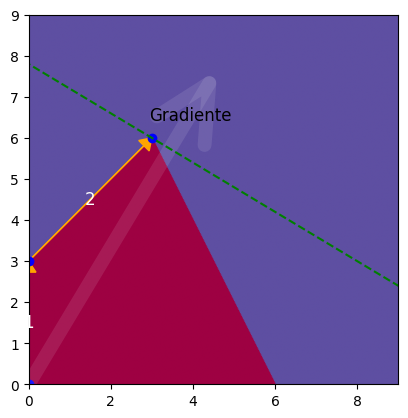

In [96]:
s1.plot_sol_history(size=9)

###  `transform_to_dual()`

Además, hemos implementado un método que nos permite transformar un problema de simplex primal en su versión dual, usamos como ejemplo el problema del examen.

$$
\begin{array}{rcl}
\begin{aligned}
\argmax \quad & z = c^T x \\
\text{s.a.} \quad & A x \le b \\
& x \ge 0
\end{aligned}
& \Longrightarrow &
\begin{aligned}
\argmin \quad & z = b^T y \\
\text{s.a.} \quad & A^T y \ge c \\
& y \ge 0
\end{aligned}
\end{array}
$$

In [97]:
ejemplo_examen = [
    [1, -1, 0, 0, 0, 0],
    [0, 2, 1, 1, 0, 10],
    [0, -1, -1, 0, 1, -3]
]

ejemplo_examen = np.array(ejemplo_examen, dtype=float)

In [ ]:
s1 = Simplex(ejemplo_examen)
print("Matriz original:")
print(s1.original_matrix)

s2 = Simplex(ejemplo_examen)
s2.transform_to_dual()
print("\n Matriz dual:")
print(s2.current_matrix)

Matriz primal:
[[ 1. -1.  0.  0.  0.  0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 Matriz dual:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]


Luego, ambos problemas pueden ser resueltos con el mismo objeto `Simplex`, usando el metodo `solver` y especificando la versión que queremos usar.

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3]
- Argumentos actuales: [10. -3.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 2]
- Argumentos actuales: [3. 7.]
- Punto actual: [0. 3.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[ 1.  1.  0.  0.  0.  0.]
 [ 0.  1.  1.  0. -1.  3.]
 [ 0.  1.  0.  1.  1.  7.]]

 - Matriz original:
[[ 1.  1. -0. -0. -0. -0.]
 [ 0.  2.  1.  1.  0. 10.]
 [ 0. -1. -1.  0.  1. -3.]]
------------------------------------------------------------
-------------------ITERANDO CON EL PRIMAL---

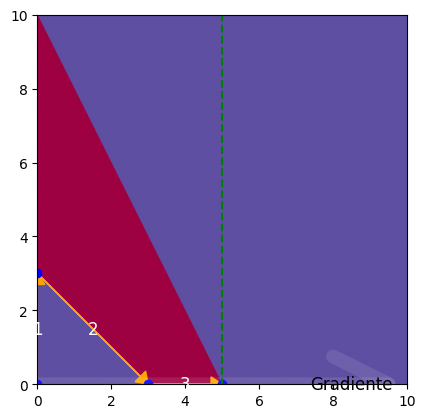

In [99]:
s1.combined_solver()
s1.plot_sol_history()

Y plotear el historial del dual.

------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3]
- Argumentos actuales: [-1.  0.]
- Punto actual: [0. 0.]
- Valor objetivo actual: 0.0

 - Matriz actual:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]

 - Matriz original:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [0 3]
- Argumentos actuales: [0.5 0.5]
- Punto actual: [0.5 0. ]
- Valor objetivo actual: 5.0

 - Matriz actual:
[[ 1.   0.  -2.  -5.   0.   5. ]
 [ 0.   1.  -0.5 -0.5  0.   0.5]
 [ 0.   0.   0.5 -0.5  1.   0.5]]

 - Matriz original:
[[  1. -10.   3.   0.   0.   0.]
 [  0.  -2.   1.   1.   0.  -1.]
 [  0.  -1.   1.   0.   1.   0.]]
------------------------------------------------------------


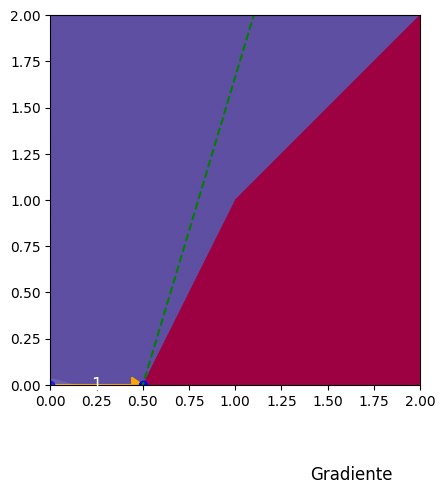

In [100]:
s2.solver(version='dual', printear_intermedios=True, return_history=True)
s2.plot_sol_history(size=2)

Además, utilizando los Teoremas de holgura complementaria y de dualidad fuerte, podemos recuperar la solución primal a partir de la solución dual, usando el método <br>
 ### `get_primal_solution_from_dual_solution(printear = True)`.

In [101]:
primal_sol = s2.get_primal_solution_from_dual_solution(printear = True)

------------------------------------------------------------
Solución del problema primal obtenida desde la solución del dual:
Base primal: [3 0]
Punto primal: [5. 0.]
Valor objetivo: 5.0
------------------------------------------------------------


In [102]:
print("Solución primal recuperado:", primal_sol)
print("Solucion primal directo:", s1.point)

print("Valor objetivo primal recuperado:", s2.objective_value)
print("Valor objetivo primal directo:", s1.objective_value)

Solución primal recuperado: [5.0, 0]
Solucion primal directo: [5.0, 0]
Valor objetivo primal recuperado: 5.0
Valor objetivo primal directo: 5.0


Ambos resultados coinciden, ahora podemos elegir cual de los métodos usar para ahorrar iteraciones o disminuir el numero de restricciones para evitar hacer inversas de matrices muy grandes.
En el ejemplo del examen, se podía resolver pasando al problema dual, en una sola iteración.

### `combined_solver()`

Este método implementa el algoritmo del simplex combinado, y lo usamos para un problema donde el origen de coordenadas sea no factible para simplex primal.

In [103]:
ejemplo_dual = [
    [1, -3, -2, 0, 0, 0, 0, 0, 0],
    [0, -1, -1, 1, 0, 0, 0, 0, -2],
    [0, 1, 2, 0, 1, 0, 0, 0, 8],
    [0, 2, 1, 0, 0, 1, 0, 0, 8],
    [0, 1, -1, 0, 0, 0, 1, 0, 1],
    [0, -1, 1, 0, 0, 0, 0, 1, 1]
]

ejemplo_dual = np.array(ejemplo_dual, dtype=float)

In [104]:
s1 = Simplex(ejemplo_dual)
s1.combined_solver()

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [2 3 4 5 6]
- Argumentos actuales: [-2.  8.  8.  1.  1.]
- Punto actual: [0. 0.]
- Valor objetivo actual: -0.0

 - Matriz actual:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]

 - Matriz original:
[[ 1.  3.  2. -0. -0. -0. -0. -0. -0.]
 [ 0. -1. -1.  1.  0.  0.  0.  0. -2.]
 [ 0.  1.  2.  0.  1.  0.  0.  0.  8.]
 [ 0.  2.  1.  0.  0.  1.  0.  0.  8.]
 [ 0.  1. -1.  0.  0.  0.  1.  0.  1.]
 [ 0. -1.  1.  0.  0.  0.  0.  1.  1.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 1
- Base actual: [1 3 4 5 6]
- Argumentos actuales: [ 2.  4.  6.  3. -1.]
- Punto actual: [0

c:\Users\jcarr\Desktop\Universidad\3º Año\1º Cuatrimestre\IO\Práctica 1\io-practica1\simplex.py:84: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


Ploteamos el historial que se ha generado:

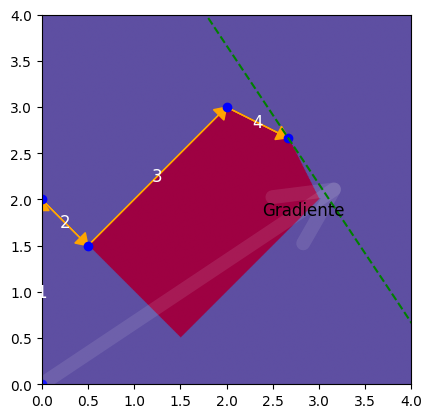

In [105]:
s1.plot_sol_history(size=4)

## Módulo `l1_svm`

Este módulo hace uso de la clase `Simplex` para implementar un clasificador SVM eligiendo la norma L1 en lugar de la norma L2 habitual.

### `generar_datos_svm(n_samples=N, random_state=SEED)`

Genera un conjunto de datos aleatorios para entrenar un clasificador SVM, se generan con centros separados, pero no tienen por qué ser linealmente separables.

In [19]:
X, y = l1_svm.generar_datos_svm(100, random_state=42)

In [20]:
DataFrame(np.concatenate((X, y.reshape(-1, 1)), axis=1), columns=['X1', 'X2', 'Y'])

,X1,X2,Y
0,-3.707133,8.550139,-1.0
1,7.347507,4.607675,1.0
2,-3.870154,9.291593,-1.0
3,6.695029,6.715152,1.0
4,5.208529,5.241027,1.0
...,...,...,...
95,0.068301,11.342486,-1.0
96,-0.220692,9.836164,-1.0
97,2.522895,-1.813948,1.0
98,-3.058377,9.907068,-1.0


### `generate_svm_matrix(X, y, C)`

Genera la matriz de simplex primal correspondiente al problema L1-SVM, a partir de los datos de entrada `X` e `y`, y el parámetro `C`.

In [21]:
C = 0.1

DataFrame(l1_svm.generate_svm_matrix(X, y, C))

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,1.0,0.500000,0.500000,0.500000,0.500000,0.0,0.0,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0
1,0.0,-3.707133,8.550139,3.707133,-8.550139,1.0,-1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,0.0,-7.347507,-4.607675,7.347507,4.607675,-1.0,1.0,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,0.0,-3.870154,9.291593,3.870154,-9.291593,1.0,-1.0,0.0,0.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
4,0.0,-6.695029,-6.715152,6.695029,6.715152,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.0,0.068301,11.342486,-0.068301,-11.342486,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0
97,0.0,-0.220692,9.836164,0.220692,-9.836164,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.0
98,0.0,-2.522895,1.813948,2.522895,-1.813948,-1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0
99,0.0,-3.058377,9.907068,3.058377,-9.907068,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0


### `solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True):`

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205]
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
- Punto act

/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:117: RuntimeWarning: overflow encountered in divide
  cocients = np.abs(numerators[mask] / denominators[mask])


[[ 1.    0.   -1.   ...  0.   -0.    2.07]
 [ 0.    1.    0.   ...  0.    0.    0.15]
 [ 0.    0.   -1.   ...  0.    0.    0.04]
 ...
 [ 0.    0.    0.   ...  0.    0.   -0.49]
 [ 0.    0.   -0.   ...  1.    0.   -0.06]
 [ 0.    0.    0.   ...  0.    1.   -0.21]]

 - Matriz original:
[[ 1. -0. -0. ... -0. -0. -0.]
 [ 0. -4.  9. ...  0.  0. -1.]
 [ 0. -7. -5. ...  0.  0. -1.]
 ...
 [ 0. -3.  2. ...  0.  0. -1.]
 [ 0. -3. 10. ...  1.  0. -1.]
 [ 0. -2.  8. ...  0.  1. -1.]]
------------------------------------------------------------
------------------------------------------------------------

- Iteracion 73
- Base actual: [  0   3   4   6   8   9  10  11  12  13  14  15  16  17  18  20  21  22
  23  24  25  26  27  28  30  31  32  33  34  35  36  37  38  39  40  41
  42  43  44  45  46  48  49  50  51  53  54  55  57  58  60  64  65  69
  71  74  84  85  88  90  95 103 107 119 129 147 156 159 161 162 163 166
 167 168 170 172 173 175 176 178 179 180 181 182 183 186 187 191 192 193
 194 

/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:84: RuntimeWarning: divide by zero encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]
/home/hector/Escritorio/3 carrera/Investigacion operativa/io-practica1/simplex.py:84: RuntimeWarning: overflow encountered in divide
  cocients = self.b_submatrix / self.A_submatrix[:, B_in]


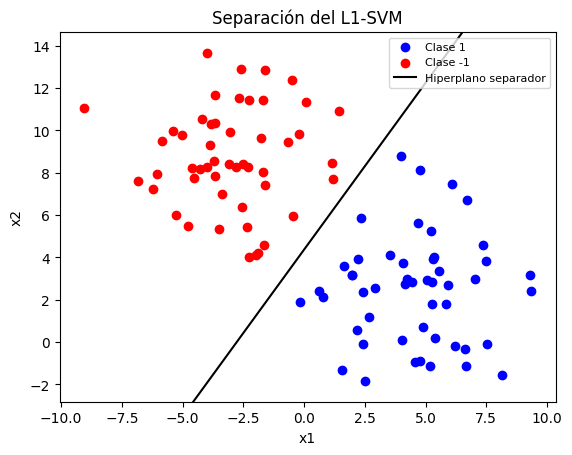

Accuracy = 1.0


In [22]:
l1_svm.solve_simplex_svm(X, y, C, print_sol = True, plot=True, print_acc=True)

Por último, un ejemplo con datos generados aleatoriamente cada vez que se ejecuta la celda.

--------------------ITERANDO CON EL DUAL--------------------
------------------------------------------------------------

- Iteracion 0
- Base actual: [106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205]
- Argumentos actuales: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
- Punto act

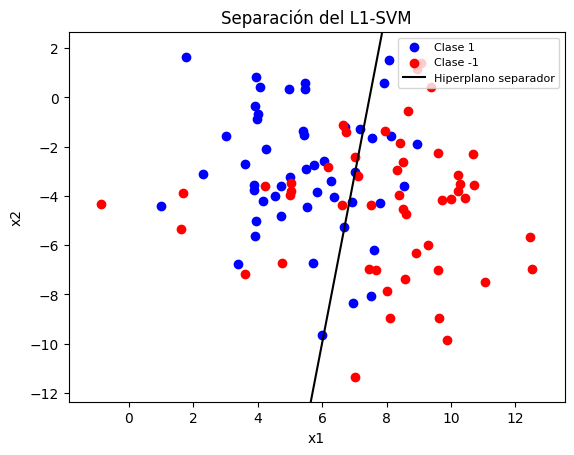

Accuracy = 0.75


In [42]:
from random import randint

SAMPLES = 100

X, y = l1_svm.generar_datos_svm(n_samples=SAMPLES, random_state=randint(1, 1000))
l1_svm.solve_simplex_svm(X, y, C=0.1, print_sol=True, plot=True, print_acc=True)
